# Compare decoders programmatically

This notebook will evaluate the accuracy and speed of a list of decoders given a specific code and noise.
It will use exactly the same sequence of syndrome such that better comparison could be done even with fewer data.

This notebook only provides basic plotting.
It considers the `none` decoder as splitter and draw multiple lines assuming the parameters in each chunk are continuous.
It will use the label of the last decoder for each chunk as the curve (but marking the changing suffix of the text as grey).

To execute this notebook with a custom code, noise and list of decoders, use
```sh
# srun --time=1-00:00:00 --mem=10G --cpus-per-task=2 \
python3 -m qec_lego_bench notebook-compare-decoder compare_decoder_example.ipynb 'rsc(d=3,p=0.01)' --decoder 'mwpf(c=0)' --decoder 'mwpf(c=50)' --decoder none --decoder 'bposd(max_iter=1)' --decoder 'bposd(max_iter=5)' --target-precision 0.1 --local-maximum-jobs 8
```

In [1]:
code: str = "rsc(d@3,p@0.01)"
noise: str = "none"
decoders: list[str] = ["mwpf"]

max_cpu_hours: float = None
target_precision: float = 0.04  # about 4000 errors for the configuration with the smallest 

slurm_maximum_jobs: int = 50  # start with a smaller number of workers to avoid resource waste
slurm_cores_per_node: int = 10  # (slurm_maximum_jobs // slurm_cores_per_node) should not exceed 200
slurm_mem_per_job: int = 4  # 4GB per job
slurm_extra: dict = dict(
    walltime = "1-00:00:00",  # adaptively shutdown if no more jobs
    queue = "scavenge",  # use with caution: dask does not seem to handle scavenge workers well
    job_extra_directives = ["--requeue"],  # use with scavenge partition will help spawn scavenged jobs
)

import multiprocessing
local_maximum_jobs: int = multiprocessing.cpu_count()

json_filename: str = None
cpu: str = "unknown"
force_finished: bool = False  # only plot the figure and do not run experiments

In [2]:
# Parameters
code = "bb(n@90,k@8,d@10)"
noise = "flip(p@0.01)"
decoders = ["mwpf(c@0)", "mwpf(c@1)", "mwpf(c@2)", "mwpf(c@3)", "mwpf(c@4)", "mwpf(c@5)", "mwpf(c@6)", "mwpf(c@7)", "mwpf(c@8)", "mwpf(c@9)", "mwpf(c@10)", "mwpf(c@15)", "mwpf(c@20)", "mwpf(c@25)", "mwpf(c@30)", "mwpf(c@35)", "mwpf(c@40)", "mwpf(c@45)", "mwpf(c@50)", "mwpf(c@100)", "mwpf(c@150)", "mwpf(c@200)", "mwpf(c@300)", "mwpf(c@500)", "mwpf(c@1000)", "none", "bposd(max_iter@50;ms_scaling_factor@0.9)", "bposd(max_iter@100;ms_scaling_factor@0.9)", "bposd(max_iter@600;ms_scaling_factor@0.9)", "bposd(max_iter@1000;ms_scaling_factor@0.9)", "bposd(max_iter@6000;ms_scaling_factor@0.9)"]
json_filename = "capacity-bb-flip.bb-n-90-k-8-d-10.flip-p-0-01.json"
target_precision = 0.04
local_maximum_jobs = 6


In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
code = code.replace("@", "=")
noise = noise.replace("@", "=")
decoders = [decoder.replace("@", "=") for decoder in decoders]

from qec_lego_bench.notebooks.compare_decoder import *

if json_filename is None:
    json_filename = default_json_filename(code=code, noise=noise)
print("saving results to:", json_filename)


saving results to: capacity-bb-flip.bb-n-90-k-8-d-10.flip-p-0-01.json


### Define the Monte Carlo job function

In [5]:
jobs = [MonteCarloJob(code=code, noise=noise)]

monte_carlo_function = CompareDecoderMonteCarloFunction(
    decoders=decoders,
)

if not force_finished:
    print(monte_carlo_function(10, code=code, noise=noise, verbose=True))

Writing Circuit file to /var/folders/x4/zy4mgv3950q4s06099xx0h2w0000gn/T/tmpyjd32p1y/tmp.stim
Writing DEM file to /var/folders/x4/zy4mgv3950q4s06099xx0h2w0000gn/T/tmpyjd32p1y/tmp.dem
Writing detectors to /var/folders/x4/zy4mgv3950q4s06099xx0h2w0000gn/T/tmpyjd32p1y/tmp.det.b8 and observables to /var/folders/x4/zy4mgv3950q4s06099xx0h2w0000gn/T/tmpyjd32p1y/tmp.obs.b8



  0%|                                                                                                  | 0/31 [00:00<?, ?it/s]


 10%|████████▋                                                                                 | 3/31 [00:00<00:01, 21.96it/s]


 19%|█████████████████▍                                                                        | 6/31 [00:00<00:01, 21.95it/s]


 29%|██████████████████████████▏                                                               | 9/31 [00:00<00:00, 22.11it/s]

...


 58%|███████████████████████████████████████████████████▋                                     | 18/31 [00:00<00:00, 22.45it/s]


 68%|████████████████████████████████████████████████████████████▎                            | 21/31 [00:00<00:00, 22.53it/s]


 77%|████████████████████████████████████████████████████████████████████▉                    | 24/31 [00:01<00:00, 22.61it/s]


100%|█████████████████████████████████████████████████████████████████████████████████████████| 31/31 [00:01<00:00, 27.43it/s]

(10, MultiDecoderLogicalErrorRates(results={'mwpf(c=0)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=0.022554041002877057), 'mwpf(c=1)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=0.00012911998459862338), 'mwpf(c=2)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=0.0002954167171588375), 'mwpf(c=3)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=0.022148541000206023), 'mwpf(c=4)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=0.0005483333370648324), 'mwpf(c=5)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=0.0001724544239954816), 'mwpf(c=6)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=0.000489722232386056), 'mwpf(c=7)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=0.0009881489030602905), 'mwpf(c=8)': LogicalErrorResult(errors=0, discards=0, panic_cases=None, elapsed=8.99544425515665e-05), 'mwpf(c=9)': LogicalErr

### Define the strategy to submit jobs

In [6]:
precision_submitter = PrecisionSubmitter(
    time_limit=max_cpu_hours * 3600 if max_cpu_hours is not None else None,
    min_precision=None,
    target_precision=target_precision,
)

def submitter(executor: MonteCarloJobExecutor) -> list[tuple[MonteCarloJob, int]]:
    submit = precision_submitter(executor)
    return submit

## The rest of the notebook runs the evaluation

In [7]:
config = MonteCarloExecutorConfig()
config.max_submitted_job = max(config.max_submitted_job, 3 * slurm_maximum_jobs)
executor = MonteCarloJobExecutor(
    monte_carlo_function,
    jobs,
    config=config,
    filename=json_filename,
    result_type=MultiDecoderLogicalErrorRates,
)

client_connector = SlurmClientConnector(
    slurm_maximum_jobs=slurm_maximum_jobs,
    slurm_cores_per_node=slurm_cores_per_node,
    slurm_mem_per_job=slurm_mem_per_job,
    slurm_extra=slurm_extra,
    local_maximum_jobs=local_maximum_jobs,
)

,Status,JobKey,Job,Finished,Pending,Submitted,0 jobs,Total,Duration,Errors,Discards,Panics,Error Rate
0,finished,e13e2e,"Job(code=bb(n=90,k=8,d=10), noise=flip(p=0.01))",497727399 (100%),0 (0%),0 (0%),0 (0%),497727399,444341.9s (7405.7min),5568,0,0,1.12(4)e-05


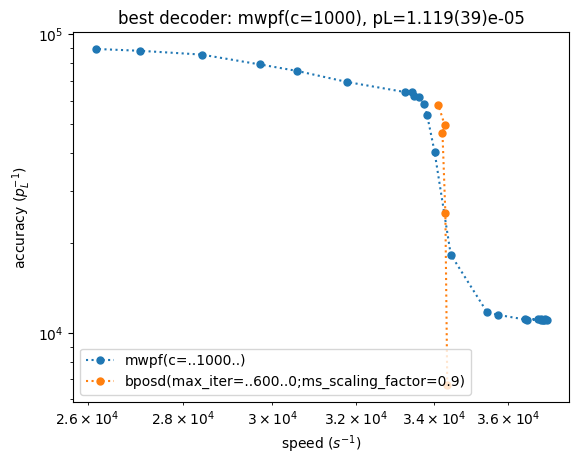

''

In [8]:
import time  # add some sleep to let them work properly in VScode Jupyter notebook

time.sleep(0.2)
progress_plotter = JobProgressPlotter()
time.sleep(0.2)
compare_decoder_plotter = CompareDecoderPlotter(
    decoders = decoders
)
time.sleep(0.2)
memory_plotter = MemoryUsagePlotter()


def callback(executor: MonteCarloJobExecutor):
    progress_plotter(executor)
    time.sleep(0.1)
    compare_decoder_plotter(executor)
    time.sleep(0.1)
    memory_plotter(executor)
    time.sleep(0.1)


executor.execute(
    client_connector=client_connector,
    submitter=submitter,
    loop_callback=callback,
    shutdown_cluster=True,
    force_finished=force_finished,
)